# SMS Spam Detection — Backtracking + Multi-Model ML

**Course project upgrade:** The original SVM-based SMS spam classifier is extended into a **Backtracking Feature Selection** problem and evaluated with multiple machine-learning models.

### Added features
- Recursive backtracking to select the best subset of handcrafted SMS features.
- TF-IDF unigram + bigram text representation.
- Hybrid feature space: TF-IDF + selected handcrafted features.
- Multiple models: Linear SVM, Logistic Regression, Multinomial Naive Bayes, SGD Classifier, Random Forest.
- Cross-validation and side-by-side model comparison.
- Confusion matrix and detailed classification report.
- User-friendly prediction function.
- Model export with `joblib`.
- Class-imbalance-aware evaluation using Spam F1 score.

**Dataset:** SMS Spam Collection (5572 messages; original notebook reports 4825 ham and 747 spam).

In [1]:
!pip -q install nltk wordcloud scikit-learn joblib

In [2]:
import re, string, os, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

nltk.download("stopwords")
nltk.download("wordnet")
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## 1. Load the dataset

Upload the `SMS.csv` file used in the original project. The code also supports the common `spam.csv` filename.

In [3]:
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

df = pd.read_csv(filename, encoding="latin-1")
# UCI/Kaggle SMS Spam Collection format
df = df.iloc[:, :2].copy()
df.columns = ["label", "message"]

df["label"] = df["label"].str.lower().map({"ham": 0, "spam": 1})
df = df.dropna(subset=["message", "label"]).drop_duplicates().reset_index(drop=True)

print("Dataset shape:", df.shape)
print(df["label"].value_counts().rename(index={0:"ham",1:"spam"}))

Saving spam.csv to spam.csv
Dataset shape: (5169, 2)
label
ham     4516
spam     653
Name: count, dtype: int64


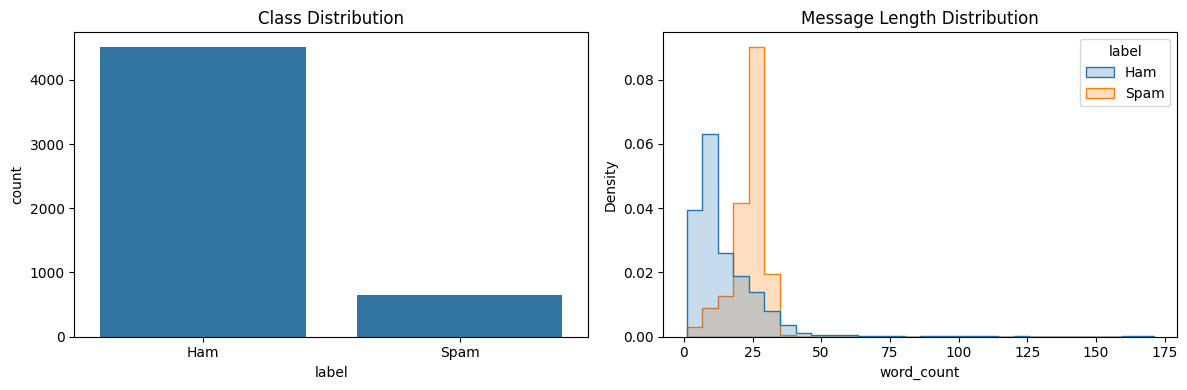

In [4]:
# Basic EDA
df["char_count"] = df["message"].str.len()
df["word_count"] = df["message"].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=df["label"].map({0:"Ham",1:"Spam"}), ax=ax[0])
ax[0].set_title("Class Distribution")
sns.histplot(data=df, x="word_count", hue=df["label"].map({0:"Ham",1:"Spam"}),
             bins=30, element="step", stat="density", common_norm=False, ax=ax[1])
ax[1].set_title("Message Length Distribution")
plt.tight_layout()
plt.show()

## 2. Text preprocessing

In [5]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"\d+", " NUMBER ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)

df["clean_message"] = df["message"].apply(clean_text)

## 3. Handcrafted SMS features

These features capture common spam signals such as links, money symbols, uppercase emphasis, exclamation marks, phone numbers, and message length.

The **Backtracking problem** is: from all candidate handcrafted features, find a compact subset that maximizes validation F1 for spam while avoiding unnecessary features.

In [6]:
def extract_features(text):
    text = str(text)
    words = text.split()
    letters = [c for c in text if c.isalpha()]
    return {
        "char_len": len(text),
        "word_len": len(words),
        "digit_count": sum(c.isdigit() for c in text),
        "upper_count": sum(c.isupper() for c in text),
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "currency_count": sum(text.count(x) for x in ["$", "£", "€"]),
        "url_count": len(re.findall(r"https?://|www\.", text.lower())),
        "phone_like": int(bool(re.search(r"(?:\+?\d[\d\s-]{7,}\d)", text))),
        "has_free": int(bool(re.search(r"\bfree\b", text.lower()))),
        "has_win": int(bool(re.search(r"\b(win|winner|won)\b", text.lower()))),
        "has_call": int(bool(re.search(r"\b(call|contact)\b", text.lower())))
    }

feature_df = pd.DataFrame(df["message"].apply(extract_features).tolist())
feature_names = list(feature_df.columns)

print("Candidate features:", feature_names)
display(feature_df.head())

Candidate features: ['char_len', 'word_len', 'digit_count', 'upper_count', 'exclamation_count', 'question_count', 'currency_count', 'url_count', 'phone_like', 'has_free', 'has_win', 'has_call']


,char_len,word_len,digit_count,upper_count,exclamation_count,question_count,currency_count,url_count,phone_like,has_free,has_win,has_call
0,111,20,0,3,0,0,0,0,0,0,0,0
1,29,6,0,2,0,0,0,0,0,0,0,0
2,155,28,25,10,0,0,0,0,1,1,1,0
3,49,11,0,2,0,0,0,0,0,0,0,0
4,61,13,0,2,0,0,0,0,0,0,0,0


## 4. Train/validation/test split

A fixed validation set is used **only by the backtracking search**. The final model is evaluated on an untouched test set.

In [7]:
X_text = df["clean_message"]
y = df["label"]

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

raw_train = df.loc[X_train_text.index, "message"]
raw_val = df.loc[X_val_text.index, "message"]
raw_test = df.loc[X_test_text.index, "message"]

F_train = feature_df.loc[X_train_text.index].reset_index(drop=True)
F_val = feature_df.loc[X_val_text.index].reset_index(drop=True)
F_test = feature_df.loc[X_test_text.index].reset_index(drop=True)

print(len(X_train_text), "train |", len(X_val_text), "validation |", len(X_test_text), "test")

3618 train | 775 validation | 776 test


## 5. Backtracking Feature Selection

### State-space view
- **State:** current subset of handcrafted features.
- **Choice:** include or exclude the next feature.
- **Goal:** maximize validation Spam F1.
- **Backtracking:** recursively explore choices and undo the last choice.
- **Pruning:** stop exploring a branch when its current size reaches the maximum allowed subset size.

This makes the feature-selection stage a genuine **backtracking problem** rather than simply calling a built-in feature selector.

In [8]:
# TF-IDF is fixed while backtracking searches over handcrafted features.
bt_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)
Xtr_tfidf = bt_tfidf.fit_transform(X_train_text)
Xv_tfidf = bt_tfidf.transform(X_val_text)

# Standardize only the handcrafted feature block.
scaler = MinMaxScaler()
Ftr_scaled = scaler.fit_transform(F_train)
Fv_scaled = scaler.transform(F_val)
F_test_scaled = scaler.transform(F_test)

# A linear model gives a fast, stable objective for the search.
bt_model = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)

MAX_SELECTED = 7
best_subset = []
best_score = -1.0
nodes_visited = 0
feature_cache = {}

def evaluate_subset(subset):
    key = tuple(subset)
    if key in feature_cache:
        return feature_cache[key]
    if not subset:
        Xtr = Xtr_tfidf
        Xv = Xv_tfidf
    else:
        cols = [feature_names.index(f) for f in subset]
        Xtr = hstack([Xtr_tfidf, csr_matrix(Ftr_scaled[:, cols])], format="csr")
        Xv = hstack([Xv_tfidf, csr_matrix(Fv_scaled[:, cols])], format="csr")
    bt_model.fit(Xtr, y_train)
    pred = bt_model.predict(Xv)
    score = f1_score(y_val, pred, pos_label=1)
    feature_cache[key] = score
    return score

def backtrack(index, selected):
    global best_subset, best_score, nodes_visited
    nodes_visited += 1

    score = evaluate_subset(selected)
    if score > best_score:
        best_score = score
        best_subset = selected.copy()

    if index == len(feature_names) or len(selected) == MAX_SELECTED:
        return

    # Choice 1: include feature
    selected.append(feature_names[index])
    backtrack(index + 1, selected)
    selected.pop()  # backtrack

    # Choice 2: exclude feature
    backtrack(index + 1, selected)

backtrack(0, [])

print("Best handcrafted subset:", best_subset)
print("Validation Spam F1:", round(best_score, 4))
print("Backtracking nodes visited:", nodes_visited)
print("Candidate features:", len(feature_names))

Best handcrafted subset: ['word_len', 'digit_count', 'upper_count', 'currency_count', 'url_count', 'phone_like', 'has_free']
Validation Spam F1: 0.9479
Backtracking nodes visited: 6603
Candidate features: 12


## 6. Build the final hybrid representation

The selected handcrafted features are appended to the TF-IDF representation. The same selected subset is used for every candidate model, making the model comparison fair.

In [9]:
selected_cols = [feature_names.index(f) for f in best_subset]

# Fit TF-IDF only on training data to avoid leakage.
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

X_train_h = csr_matrix(Ftr_scaled[:, selected_cols]) if selected_cols else csr_matrix((len(F_train), 0))
X_val_h = csr_matrix(Fv_scaled[:, selected_cols]) if selected_cols else csr_matrix((len(F_val), 0))
X_test_h = csr_matrix(F_test_scaled[:, selected_cols]) if selected_cols else csr_matrix((len(F_test), 0))

X_train_final = hstack([X_train_tfidf, X_train_h], format="csr")
X_val_final = hstack([X_val_tfidf, X_val_h], format="csr")
X_test_final = hstack([X_test_tfidf, X_test_h], format="csr")

print("Final feature matrix:", X_train_final.shape)

Final feature matrix: (3618, 5007)


## 7. Run multiple machine-learning models

In [10]:
models = {
    "Linear SVM": LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(C=2.0, max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Multinomial NB": MultinomialNB(alpha=0.5),
    "SGD Classifier": SGDClassifier(loss="modified_huber", alpha=1e-5, class_weight="balanced",
                                     max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=250, max_depth=20,
                                             class_weight="balanced", random_state=RANDOM_STATE,
                                             n_jobs=-1)
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_final, y_train)
    pred = model.predict(X_test_final)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "Spam F1": f1_score(y_test, pred, zero_division=0)
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("Spam F1", ascending=False).reset_index(drop=True)
display(results_df.style.format({c:"{:.4f}" for c in results_df.columns if c != "Model"}))

,Model,Accuracy,Precision,Recall,Spam F1
0,Multinomial NB,0.9910,0.9892,0.9388,0.9634
1,Linear SVM,0.9884,0.9684,0.9388,0.9534
2,SGD Classifier,0.9884,0.9684,0.9388,0.9534
3,Random Forest,0.9858,0.9677,0.9184,0.9424
4,Logistic Regression,0.9807,0.9109,0.9388,0.9246


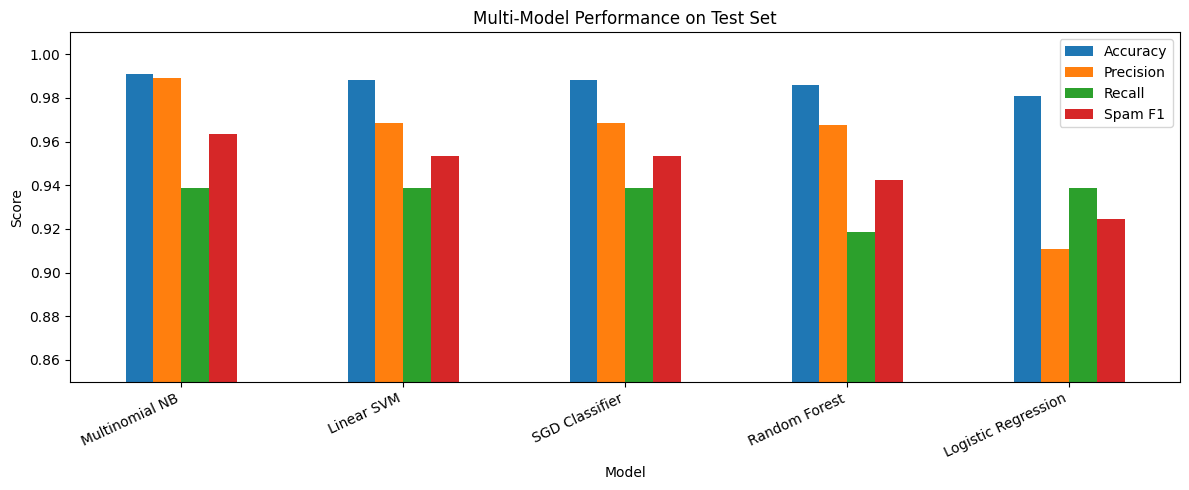

In [11]:
# Visual comparison
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "Spam F1"]]
plot_df.plot(kind="bar", figsize=(12, 5), ylim=(0.85, 1.01))
plt.title("Multi-Model Performance on Test Set")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 8. Detailed evaluation of the best model

Best model: Multinomial NB
              precision    recall  f1-score   support

         Ham     0.9912    0.9985    0.9949       678
        Spam     0.9892    0.9388    0.9634        98

    accuracy                         0.9910       776
   macro avg     0.9902    0.9687    0.9791       776
weighted avg     0.9910    0.9910    0.9909       776



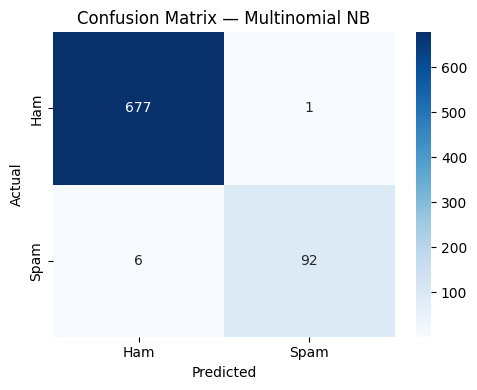

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test_final)

print("Best model:", best_model_name)
print(classification_report(y_test, best_pred, target_names=["Ham", "Spam"], digits=4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

## 9. Prediction function

The prediction function accepts a new SMS and applies exactly the same cleaning, TF-IDF transformation, scaling, and selected handcrafted features used during training.

In [13]:
def make_single_feature(text):
    row = pd.DataFrame([extract_features(text)])
    return csr_matrix(scaler.transform(row[feature_names])[:, selected_cols]) if selected_cols else csr_matrix((1,0))

def predict_sms(text):
    cleaned = clean_text(text)
    text_vec = tfidf.transform([cleaned])
    hybrid = hstack([text_vec, make_single_feature(text)], format="csr")
    pred = best_model.predict(hybrid)[0]
    return "SPAM" if pred == 1 else "HAM"

examples = [
    "Congratulations! You have won a free iPhone. Click here now!",
    "Hi, are we meeting tomorrow at 3 PM?",
    "URGENT! Claim your cash prize by calling 09012345678 now!"
]
for msg in examples:
    print(f"{predict_sms(msg):5s} -> {msg}")

SPAM  -> Congratulations! You have won a free iPhone. Click here now!
HAM   -> Hi, are we meeting tomorrow at 3 PM?
SPAM  -> URGENT! Claim your cash prize by calling 09012345678 now!


## 10. Save the trained system

The saved artifact contains the selected feature names, TF-IDF vectorizer, scaler, model, and preprocessing function so the project can be reused without retraining.

In [14]:
artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "tfidf": tfidf,
    "scaler": scaler,
    "selected_features": best_subset,
    "all_features": feature_names
}
joblib.dump(artifact, "sms_spam_backtracking_model.joblib")

results_df.to_csv("model_comparison.csv", index=False)
print("Saved: sms_spam_backtracking_model.joblib")
print("Saved: model_comparison.csv")

Saved: sms_spam_backtracking_model.joblib
Saved: model_comparison.csv


## 11. Conclusion

The original SVM-only workflow has been converted into a **hybrid SMS spam detection system with a backtracking feature-selection component**. The backtracking stage searches over handcrafted spam indicators, while TF-IDF captures the linguistic content of messages. Several classifiers are then trained on the same final representation and compared using Spam F1, precision, recall, and accuracy.

**Why backtracking is useful here:** it provides an explicit search-based optimization problem where every feature has an include/exclude decision. The recursive search can find a compact subset without relying on a library feature-selection routine.

**Important:** model scores should be taken from the notebook after execution on the uploaded dataset; they are not hard-coded in this project.